# EVALUACIÓN PARCIAL N°3 — DEEP LEARNING (DLY0100)
## Entregable 3.2 v6: Modelo Transformer para Generación de Texto

**Integrantes:**
*   Soledad Faúndez
*   Martin Osorio
*   Renato Espina
*   Esteban Olivares

**Asignatura:** Deep Learning
**Docente:** Marcelo Tapia Contreras

## Introducción

### ¿Qué es un Transformer?

El **Transformer** es una arquitectura de red neuronal introducida en *"Attention is All You Need"*
(Vaswani et al., 2017). A diferencia de las redes RNN/LSTM, que procesan las secuencias de forma
**secuencial**, el Transformer procesa **todos los tokens en paralelo** gracias al mecanismo de
**Auto-Atención (Self-Attention)**.

### Diferencias clave: LSTM vs Transformer

| Característica | LSTM | Transformer |
|---|---|---|
| Procesamiento | **Secuencial** (token a token) | **Paralelo** (todos los tokens a la vez) |
| Memoria | Estado oculto (cuello de botella) | Atención sobre toda la secuencia |
| Dependencias largas | Se degradan con distancia | Capturadas directamente vía atención |
| Velocidad de entrenamiento | Lenta (sin paralelismo) | Rápida (GPU/TPU aprovechan paralelismo) |
| Posición | Implícita en el orden de procesamiento | Explícita vía **Positional Encoding** |
| Parámetros | Menos (cell state + gates) | Más (Q, K, V proyecciones por capa) |
| Rendimiento en NLP moderno | Bueno para secuencias cortas | Superior (base de GPT, BERT, T5…) |

### Arquitectura General: Encoder-Decoder

| Componente | Función |
|---|---|
| **Encoder** | Procesa la secuencia de entrada → representación contextual |
| **Decoder** | Recibe la representación del encoder → genera la salida token a token |

### Objetivo de este Entregable

Aplicar un Transformer **Encoder-Decoder** a la tarea de **generación de texto** en español,
usando el corpus literario de *Don Quijote de la Mancha* (capítulos 1–74), evaluando con **BLEU**
y **ROUGE**, y comparando **tres configuraciones** que ilustran el efecto del control de overfitting
sobre el desempeño final.


## 1. Instalación de Dependencias y Carga de Librerías

In [ ]:
!pip install rouge-score nltk --quiet

import gdown
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

from rouge_score import rouge_scorer
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print("✓ Librerías cargadas exitosamente.")


  Preparing metadata (setup.py) ... done
TensorFlow version: 2.20.0
✓ Librerías cargadas exitosamente.


## 2. Carga y Exploración del Dataset

Se utiliza el corpus de *Don Quijote de la Mancha* (capítulos 1–74), el mismo que en el
Entregable 3.1 (LSTM), lo que permite una comparación directa entre ambas arquitecturas.

In [ ]:
file_id = '1sY9TTL-cMtKdzpVzIdYMiJqHBo2inW6D'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, 'don_quijote.txt', quiet=True)

with open('don_quijote.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

print(f"Total de caracteres: {len(raw_text):,}")
print(f"Total de líneas:     {raw_text.count(chr(10)):,}")
print(f"\nPrimeros 600 caracteres:\n{'─'*60}")
print(raw_text[:600])


Total de caracteres: 2,071,198
Total de líneas:     36,880

Primeros 600 caracteres:
────────────────────────────────────────────────────────────
Capítulo primero. Que trata de la condición y ejercicio del famoso hidalgo
don Quijote de la Mancha


En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. Una olla de algo más vaca que carnero,
salpicón las más noches, duelos y quebrantos los sábados, lantejas los
viernes, algún palomino de añadidura los domingos, consumían las tres
partes de su hacienda. El resto della concluían sayo de velarte, calzas de
velludo para las fiestas, con sus pantuflos de lo mesmo, y los dí


## 3. Preprocesamiento del Texto

A diferencia del Entregable 3.1 (LSTM a nivel de **carácter**), el Transformer trabaja a nivel
de **palabra**. Esto es más natural y permite una evaluación con métricas NLP estándar (BLEU, ROUGE).

In [ ]:
def preprocess_text(text):
    """Limpieza y normalización del texto para tokenización por palabras."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-záéíóúüñ\s.,;:!?¿¡\-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_clean = preprocess_text(raw_text)

print(f"Caracteres (original): {len(raw_text):,}")
print(f"Caracteres (limpio):   {len(text_clean):,}")
print(f"\nMuestra de texto limpio:")
print(text_clean[:500])


Caracteres (original): 2,071,198
Caracteres (limpio):   2,061,346

Muestra de texto limpio:
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo don quijote de la mancha en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lantejas los viernes, algún palomino de añadidura los domingos, consumían las tres partes de su hacienda. el resto della conc


In [ ]:
def tokenize(text):
    """Tokeniza el texto en palabras, separando la puntuación."""
    text = re.sub(r'([.,;:!?¿¡\-])', r' \1 ', text)
    return text.split()

words = tokenize(text_clean)

print(f"Total de palabras (tokens): {len(words):,}")
print(f"Palabras únicas:            {len(set(words)):,}")
print(f"\nPrimeros 30 tokens: {words[:30]}")


Total de palabras (tokens): 441,237
Palabras únicas:            22,606

Primeros 30 tokens: ['capítulo', 'primero', '.', 'que', 'trata', 'de', 'la', 'condición', 'y', 'ejercicio', 'del', 'famoso', 'hidalgo', 'don', 'quijote', 'de', 'la', 'mancha', 'en', 'un', 'lugar', 'de', 'la', 'mancha', ',', 'de', 'cuyo', 'nombre', 'no', 'quiero']


### Construcción del Vocabulario

Se seleccionan las `MAX_VOCAB_SIZE = 10 000` palabras más frecuentes.
Tokens especiales:
- `<PAD>` (0): relleno para uniformar longitudes.
- `<UNK>` (1): palabras fuera del vocabulario.
- `<START>` (2): inicio de secuencia en el decoder.
- `<END>` (3): fin de secuencia generada.

In [ ]:
PAD_TOKEN, UNK_TOKEN   = '<PAD>', '<UNK>'
START_TOKEN, END_TOKEN = '<START>', '<END>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN]

MAX_VOCAB_SIZE = 10000

word_freq   = Counter(words)
most_common = word_freq.most_common(MAX_VOCAB_SIZE - len(SPECIAL_TOKENS))

word_to_idx = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
for i, (w, _) in enumerate(most_common, start=len(SPECIAL_TOKENS)):
    word_to_idx[w] = i
idx_to_word = {i: w for w, i in word_to_idx.items()}

VOCAB_SIZE = len(word_to_idx)
PAD_IDX    = word_to_idx[PAD_TOKEN]
UNK_IDX    = word_to_idx[UNK_TOKEN]
START_IDX  = word_to_idx[START_TOKEN]
END_IDX    = word_to_idx[END_TOKEN]

total_tokens    = len(words)
in_vocab_tokens = sum(1 for w in words if w in word_to_idx)

print(f"Tamaño del vocabulario:    {VOCAB_SIZE:,}")
print(f"Palabras únicas en texto:  {len(word_freq):,}")
print(f"Cobertura del vocabulario: {in_vocab_tokens/total_tokens*100:.1f}%")
print(f"\n10 palabras más frecuentes: {[w for w,_ in most_common[:10]]}")


Tamaño del vocabulario:    10,000
Palabras únicas en texto:  22,606
Cobertura del vocabulario: 96.8%

10 palabras más frecuentes: [',', 'que', 'y', 'de', 'la', 'a', 'en', '.', 'el', '-']


### Creación de Pares de Secuencias (Fuente → Objetivo)

- **Secuencia fuente** (encoder): primeras `SRC_LEN=30` palabras de la ventana.
- **Secuencia objetivo** (decoder): las siguientes `TGT_LEN=30` palabras.
- `STRIDE=8`: controla cuántos pares se generan por desplazamiento de la ventana sobre el corpus.
  Un stride bajo genera más pares (mejor generalización) a costa de mayor redundancia entre ellos.

In [ ]:
SRC_LEN = 30
TGT_LEN = 30
STRIDE  = 8

def encode_words(word_list, word_to_idx, unk_idx):
    return [word_to_idx.get(w, unk_idx) for w in word_list]

src_seqs, tgt_seqs = [], []
window = SRC_LEN + TGT_LEN

for i in range(0, len(words) - window, STRIDE):
    src = words[i : i + SRC_LEN]
    tgt = words[i + SRC_LEN : i + window]
    src_seqs.append(encode_words(src, word_to_idx, UNK_IDX))
    tgt_seqs.append([START_IDX] + encode_words(tgt, word_to_idx, UNK_IDX) + [END_IDX])

src_seqs = np.array(src_seqs, dtype=np.int32)
tgt_seqs = np.array(tgt_seqs, dtype=np.int32)

print(f"Pares de secuencias (STRIDE={STRIDE}): {len(src_seqs):,}")
print(f"\nShape fuente:   {src_seqs.shape}")
print(f"Shape objetivo: {tgt_seqs.shape}")
print()
print("Ejemplo — Fuente:  ", ' '.join(idx_to_word[i] for i in src_seqs[0]))
print("Ejemplo — Objetivo:", ' '.join(idx_to_word[i] for i in tgt_seqs[0]))


Pares de secuencias (STRIDE=8): 55,148

Shape fuente:   (55148, 30)
Shape objetivo: (55148, 32)

Ejemplo — Fuente:   capítulo primero . que trata de la condición y ejercicio del famoso hidalgo don quijote de la mancha en un lugar de la mancha , de cuyo nombre no quiero
Ejemplo — Objetivo: <START> acordarme , no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero , adarga antigua , rocín flaco y galgo corredor . una olla de algo <END>


In [ ]:
np.random.seed(42)
perm = np.random.permutation(len(src_seqs))
src_seqs, tgt_seqs = src_seqs[perm], tgt_seqs[perm]

X_train_src, X_temp_src, y_train_tgt, y_temp_tgt = train_test_split(
    src_seqs, tgt_seqs, test_size=0.30, random_state=42
)
X_val_src, X_test_src, y_val_tgt, y_test_tgt = train_test_split(
    X_temp_src, y_temp_tgt, test_size=0.50, random_state=42
)

def split_tgt(tgt):
    return tgt[:, :-1], tgt[:, 1:]

train_dec_in,  train_dec_out = split_tgt(y_train_tgt)
val_dec_in,    val_dec_out   = split_tgt(y_val_tgt)
test_dec_in,   test_dec_out  = split_tgt(y_test_tgt)

print(f"Train      → src:{X_train_src.shape}  dec_in:{train_dec_in.shape}  dec_out:{train_dec_out.shape}")
print(f"Validación → src:{X_val_src.shape}   dec_in:{val_dec_in.shape}   dec_out:{val_dec_out.shape}")
print(f"Test       → src:{X_test_src.shape}   dec_in:{test_dec_in.shape}   dec_out:{test_dec_out.shape}")


Train      → src:(38603, 30)  dec_in:(38603, 31)  dec_out:(38603, 31)
Validación → src:(8272, 30)   dec_in:(8272, 31)   dec_out:(8272, 31)
Test       → src:(8273, 30)   dec_in:(8273, 31)   dec_out:(8273, 31)


## 4. Implementación de la Arquitectura Transformer

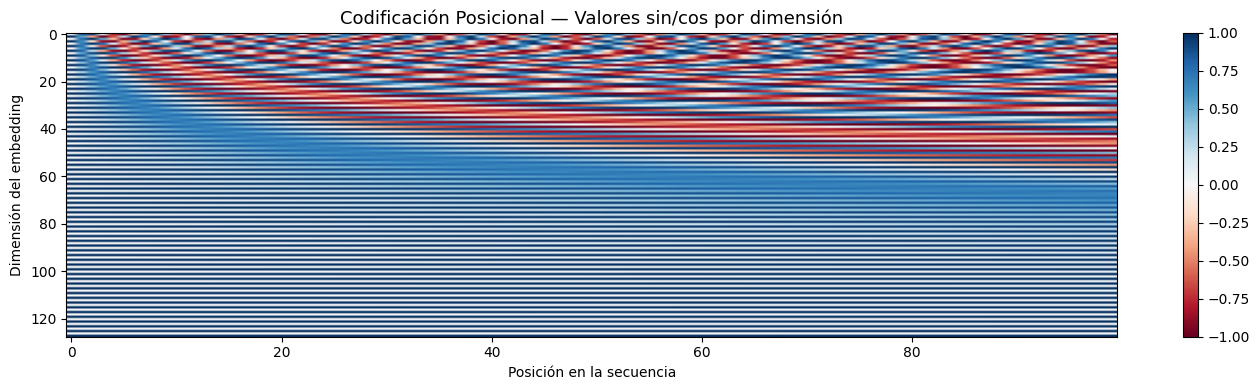

Cada columna es el vector de posición de un token. Nótese el patrón sinusoidal único por posición.


In [ ]:
class PositionalEncoding(layers.Layer):
    """
    Codificación Posicional sinusoidal (Vaswani et al., 2017).
    Almacenada como peso NO entrenable para compatibilidad con Keras 3 / TF >= 2.16.
    """
    def __init__(self, max_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_length = max_length
        self.d_model    = d_model
        positions = np.arange(max_length)[:, np.newaxis]
        dims      = np.arange(d_model)[np.newaxis, :]
        angles    = positions / np.power(10000, (2*(dims//2)) / np.float32(d_model))
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self._pe_init = angles[np.newaxis, :, :].astype(np.float32)

    def build(self, input_shape):
        self.pe = self.add_weight(
            name='sinusoidal_pe',
            shape=(1, self.max_length, self.d_model),
            initializer=tf.keras.initializers.Constant(self._pe_init),
            trainable=False, dtype='float32'
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, dtype='float32')
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'max_length': self.max_length, 'd_model': self.d_model})
        return cfg

# Visualización
pos_enc_demo = PositionalEncoding(max_length=100, d_model=128)
pe_values = pos_enc_demo(tf.zeros((1, 100, 128)))[0].numpy()

plt.figure(figsize=(14, 4))
plt.imshow(pe_values.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Codificación Posicional — Valores sin/cos por dimensión', fontsize=13)
plt.xlabel('Posición en la secuencia')
plt.ylabel('Dimensión del embedding')
plt.tight_layout()
plt.show()
print("Cada columna es el vector de posición de un token. Nótese el patrón sinusoidal único por posición.")


### 4.2 Atención Multi-Cabezal (Multi-Head Attention) — Bloque Encoder

In [ ]:
class TransformerEncoderBlock(layers.Layer):
    """
    Bloque básico del Encoder.
    Sub-capas: Multi-Head Self-Attention + FFN, cada una con Residual + LayerNorm.
    Soporta activación configurable (relu o gelu) y arquitectura pre_norm / post_norm.
    """
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1,
                 activation='relu', pre_norm=False, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.num_heads    = num_heads
        self.ff_dim       = ff_dim
        self.dropout_rate = dropout_rate
        self.activation   = activation
        self.pre_norm     = pre_norm

        self.mha   = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, name='enc_self_attn'
        )
        self.drop1 = layers.Dropout(dropout_rate)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn1  = layers.Dense(ff_dim, activation=activation)
        self.ffn2  = layers.Dense(d_model)
        self.drop2 = layers.Dropout(dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, training=False):
        if self.pre_norm:
            attn = self.mha(query=self.norm1(x), value=self.norm1(x),
                            key=self.norm1(x), training=training)
            out1 = x + self.drop1(attn, training=training)
            ffn  = self.ffn2(self.ffn1(self.norm2(out1)))
            return out1 + self.drop2(ffn, training=training)
        else:
            attn = self.mha(query=x, value=x, key=x, training=training)
            out1 = self.norm1(x + self.drop1(attn, training=training))
            ffn  = self.ffn2(self.ffn1(out1))
            return self.norm2(out1 + self.drop2(ffn, training=training))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'d_model': self.d_model, 'num_heads': self.num_heads,
                    'ff_dim': self.ff_dim, 'dropout_rate': self.dropout_rate,
                    'activation': self.activation, 'pre_norm': self.pre_norm})
        return cfg

print("✓ TransformerEncoderBlock definido (Post-Norm y Pre-Norm)")


✓ TransformerEncoderBlock definido (Post-Norm y Pre-Norm)


### 4.4 Bloque Decoder

In [ ]:
class TransformerDecoderBlock(layers.Layer):
    """
    Bloque básico del Decoder.
    Sub-capas: Masked Self-Attention + Cross-Attention + FFN, cada una con Residual + LayerNorm.
    """
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1,
                 activation='relu', pre_norm=False, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.num_heads    = num_heads
        self.ff_dim       = ff_dim
        self.dropout_rate = dropout_rate
        self.activation   = activation
        self.pre_norm     = pre_norm

        self.self_attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, name='dec_self_attn'
        )
        self.drop1 = layers.Dropout(dropout_rate)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)

        self.cross_attn = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, name='dec_cross_attn'
        )
        self.drop2 = layers.Dropout(dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.ffn1  = layers.Dense(ff_dim, activation=activation)
        self.ffn2  = layers.Dense(d_model)
        self.drop3 = layers.Dropout(dropout_rate)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, enc_output, training=False):
        if self.pre_norm:
            a1   = self.self_attn(query=self.norm1(x), value=self.norm1(x),
                                  key=self.norm1(x), use_causal_mask=True, training=training)
            out1 = x + self.drop1(a1, training=training)
            a2   = self.cross_attn(query=self.norm2(out1), value=enc_output,
                                   key=enc_output, training=training)
            out2 = out1 + self.drop2(a2, training=training)
            ffn  = self.ffn2(self.ffn1(self.norm3(out2)))
            return out2 + self.drop3(ffn, training=training)
        else:
            a1   = self.self_attn(query=x, value=x, key=x,
                                  use_causal_mask=True, training=training)
            out1 = self.norm1(x + self.drop1(a1, training=training))
            a2   = self.cross_attn(query=out1, value=enc_output, key=enc_output,
                                   training=training)
            out2 = self.norm2(out1 + self.drop2(a2, training=training))
            ffn  = self.ffn2(self.ffn1(out2))
            return self.norm3(out2 + self.drop3(ffn, training=training))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'d_model': self.d_model, 'num_heads': self.num_heads,
                    'ff_dim': self.ff_dim, 'dropout_rate': self.dropout_rate,
                    'activation': self.activation, 'pre_norm': self.pre_norm})
        return cfg

print("✓ TransformerDecoderBlock definido (Post-Norm y Pre-Norm)")


✓ TransformerDecoderBlock definido (Post-Norm y Pre-Norm)


### 4.5 Modelo Transformer Completo (Encoder-Decoder)

In [ ]:
class TransformerModel(tf.keras.Model):
    """
    Transformer Encoder-Decoder completo como subclase de keras.Model.

    Parámetros 'activation' (relu/gelu) y 'pre_norm' permiten configurar las
    distintas variantes que se comparan en este notebook.
    """
    def __init__(self, vocab_size, d_model=128, num_heads=4, ff_dim=256,
                 num_enc_layers=2, num_dec_layers=2, dropout_rate=0.1,
                 max_pos=500, activation='relu', pre_norm=False, **kwargs):
        super().__init__(**kwargs)
        self.scale = float(np.sqrt(d_model))

        self.enc_emb    = layers.Embedding(vocab_size, d_model, name='enc_emb')
        self.enc_pos    = PositionalEncoding(max_pos, d_model, name='enc_pos')
        self.enc_drop   = layers.Dropout(dropout_rate)
        self.enc_blocks = [
            TransformerEncoderBlock(d_model, num_heads, ff_dim, dropout_rate,
                                    activation=activation, pre_norm=pre_norm,
                                    name=f'enc_block_{i+1}')
            for i in range(num_enc_layers)
        ]

        self.dec_emb    = layers.Embedding(vocab_size, d_model, name='dec_emb')
        self.dec_pos    = PositionalEncoding(max_pos, d_model, name='dec_pos')
        self.dec_drop   = layers.Dropout(dropout_rate)
        self.dec_blocks = [
            TransformerDecoderBlock(d_model, num_heads, ff_dim, dropout_rate,
                                    activation=activation, pre_norm=pre_norm,
                                    name=f'dec_block_{i+1}')
            for i in range(num_dec_layers)
        ]

        self.final_norm = layers.LayerNormalization(epsilon=1e-6) if pre_norm else None
        self.out_proj   = layers.Dense(vocab_size, name='output_projection')

    def call(self, inputs, training=False):
        enc_in, dec_in = inputs

        x = tf.cast(self.enc_emb(enc_in), tf.float32) * self.scale
        x = self.enc_pos(x)
        x = self.enc_drop(x, training=training)
        for block in self.enc_blocks:
            x = block(x, training=training)
        enc_output = x

        y = tf.cast(self.dec_emb(dec_in), tf.float32) * self.scale
        y = self.dec_pos(y)
        y = self.dec_drop(y, training=training)
        for block in self.dec_blocks:
            y = block(y, enc_output, training=training)

        if self.final_norm is not None:
            y = self.final_norm(y)

        return self.out_proj(y)

print("✓ TransformerModel definido (con soporte Pre-Norm/Post-Norm y ReLU/GeLU)")


✓ TransformerModel definido (con soporte Pre-Norm/Post-Norm y ReLU/GeLU)


## 5. Utilidades de Entrenamiento

**Decisiones para controlar el overfitting (aplicadas a los tres modelos):**

- **Label Smoothing (eps=0.1):** evita que el modelo sea "demasiado seguro" de la palabra siguiente,
  suavizando los targets. Actúa como regularizador y mejora la calibración del modelo, lo que se
  traduce en mejor BLEU.
- **AdamW (Adam + weight decay):** penaliza pesos grandes de forma desacoplada del learning rate,
  reduciendo la capacidad del modelo de memorizar el set de entrenamiento.
- **Dropout calibrado por tamaño de modelo:** los modelos con más parámetros usan dropout más alto.
- **Gradient Clipping (norm=1.0):** estabiliza el entrenamiento, evitando saltos que dificultan la
  generalización.
- **Early Stopping sobre `val_loss` con `restore_best_weights=True`:** corta el entrenamiento en el
  punto de mejor generalización, antes de que el modelo empiece a sobreajustar.

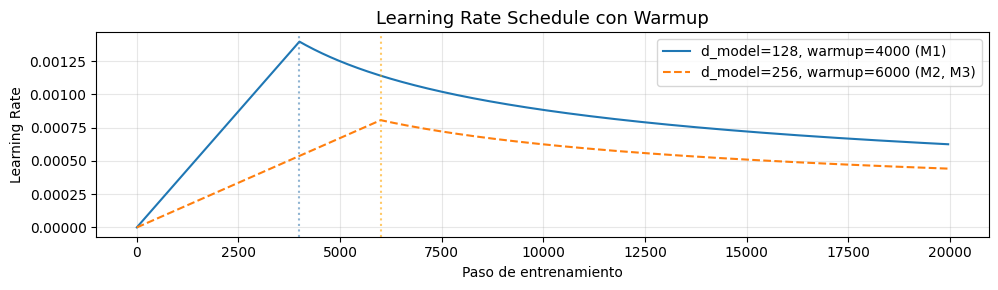

✓ Loss (Label Smoothing), Accuracy y LR Schedule definidos
✓ Gradient Clipping (clipnorm=1.0) y AdamW (weight decay) se aplican en cada modelo


In [ ]:
def masked_label_smoothing_loss(smoothing=0.1):
    """
    Label Smoothing Loss con máscara PAD (Szegedy et al., 2016).

    En lugar de targets duros (0/1), usa distribuciones suaves:
       y_smooth = y_true * (1 - eps) + eps / vocab_size

    Se usa en los tres modelos como medida de regularización adicional.
    """
    def loss_fn(y_true, y_pred):
        vocab_size = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        y_true_int = tf.cast(y_true, tf.int32)
        y_true_oh  = tf.one_hot(y_true_int, tf.shape(y_pred)[-1])
        y_smooth   = y_true_oh * (1.0 - smoothing) + (smoothing / vocab_size)
        log_probs  = tf.nn.log_softmax(y_pred, axis=-1)
        loss       = -tf.reduce_sum(y_smooth * log_probs, axis=-1)
        mask       = tf.cast(tf.not_equal(y_true, PAD_IDX), loss.dtype)
        return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-9)
    return loss_fn

def masked_accuracy(y_true, y_pred):
    """Accuracy ignorando posiciones PAD."""
    pred  = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
    truth = tf.cast(y_true, tf.int32)
    ok    = tf.cast(tf.equal(pred, truth), tf.float32)
    mask  = tf.cast(tf.not_equal(truth, PAD_IDX), tf.float32)
    return tf.reduce_sum(ok * mask) / (tf.reduce_sum(mask) + 1e-9)

class TransformerLRSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    LR Schedule con warmup lineal (Vaswani et al., 2017).
    Sube el LR linealmente durante warmup_steps y luego decae proporcional a 1/sqrt(step).
    """
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32) + 1.0
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

    def get_config(self):
        return {'d_model': int(self.d_model.numpy()),
                'warmup_steps': self.warmup_steps}

# Visualizar el schedule
steps      = np.arange(1, 20001)
lr_128_4k  = [TransformerLRSchedule(128, 4000)(s).numpy() for s in steps[::40]]
lr_256_6k  = [TransformerLRSchedule(256, 6000)(s).numpy() for s in steps[::40]]

plt.figure(figsize=(10, 3))
plt.plot(steps[::40], lr_128_4k, label='d_model=128, warmup=4000 (M1)')
plt.plot(steps[::40], lr_256_6k, label='d_model=256, warmup=6000 (M2, M3)', linestyle='--')
plt.axvline(4000, color='steelblue', linestyle=':', alpha=0.6)
plt.axvline(6000, color='orange',    linestyle=':', alpha=0.6)
plt.title('Learning Rate Schedule con Warmup', fontsize=13)
plt.xlabel('Paso de entrenamiento'); plt.ylabel('Learning Rate')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("✓ Loss (Label Smoothing), Accuracy y LR Schedule definidos")
print("✓ Gradient Clipping (clipnorm=1.0) y AdamW (weight decay) se aplican en cada modelo")


In [ ]:
def plot_history(history, title=''):
    """Grafica pérdida y accuracy de entrenamiento y validación."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss',  linestyle='--')
    ax1.set_title(f'Pérdida — {title}')
    ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['masked_accuracy'],     label='Train Accuracy')
    ax2.plot(history.history['val_masked_accuracy'], label='Val Accuracy', linestyle='--')
    ax2.set_title(f'Accuracy (sin PAD) — {title}')
    ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

def overfitting_gap(history):
    """
    Calcula la brecha train-val en la última época (proxy simple de overfitting):
    valores grandes en 'loss_gap' o 'acc_gap' indican mayor sobreajuste.
    """
    loss_gap = history.history['val_loss'][-1] - history.history['loss'][-1]
    acc_gap  = history.history['masked_accuracy'][-1] - history.history['val_masked_accuracy'][-1]
    return {'loss_gap': loss_gap, 'acc_gap': acc_gap}

print("✓ Funciones de visualización y diagnóstico de overfitting definidas")


✓ Funciones de visualización y diagnóstico de overfitting definidas


## 6. Entrenamiento y Ajuste de Hiperparámetros

Se entrenan **tres configuraciones**, pensadas explícitamente para mostrar el efecto de las
medidas de regularización sobre el overfitting:

| | **M1 — Base** | **M2 — Alta capacidad regularizada** | **M3 — Final (Pre-Norm)** |
|---|---|---|---|
| d_model | 128 | 256 | 256 |
| num_heads | 4 | 8 | 8 |
| ff_dim | 256 | 512 | 512 |
| capas enc/dec | 2 / 2 | 3 / 3 | 3 / 3 |
| dropout | 0.10 | **0.30** | 0.20 |
| activación FFN | ReLU | GeLU | GeLU |
| normalización | Post-Norm | Post-Norm | **Pre-Norm** |
| weight decay (AdamW) | 1e-4 | **1e-2** | 5e-3 |
| label smoothing | eps=0.1 | eps=0.1 | eps=0.1 |
| warmup_steps | 4000 | 6000 | 6000 |
| batch_size | 64 | 128 | 128 |
| max_epochs / patience | 40 / 6 | 60 / 8 | 70 / 10 |

**M2** es deliberadamente el modelo de mayor capacidad (más parámetros) y por eso recibe el
dropout y el weight decay más altos: es el que más riesgo de overfitting tiene si no se regulariza
con fuerza. **M3** combina Pre-Norm (mejor estabilidad de gradientes) con una regularización algo
más moderada que M2, porque Pre-Norm + Label Smoothing ya aportan parte del efecto regularizador.

### Modelo 1 — Base (d=128, 2 capas, ReLU, Post-Norm)

In [ ]:
np.random.seed(42); tf.random.set_seed(42)

modelo1 = TransformerModel(
    vocab_size=VOCAB_SIZE, d_model=128, num_heads=4, ff_dim=256,
    num_enc_layers=2, num_dec_layers=2, dropout_rate=0.10,
    activation='relu', pre_norm=False, name='M1_Base'
)

lr_schedule1 = TransformerLRSchedule(d_model=128, warmup_steps=4000)
modelo1.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule1, weight_decay=1e-4,
        beta_1=0.9, beta_2=0.98, epsilon=1e-9, clipnorm=1.0
    ),
    loss=masked_label_smoothing_loss(smoothing=0.1),
    metrics=[masked_accuracy]
)

_ = modelo1([X_train_src[:2], train_dec_in[:2]], training=False)
modelo1.summary()


In [ ]:
early_stop1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)

hist1 = modelo1.fit(
    x=[X_train_src, train_dec_in], y=train_dec_out,
    batch_size=64, epochs=40,
    validation_data=([X_val_src, val_dec_in], val_dec_out),
    callbacks=[early_stop1], verbose=1
)
print(f"\n✓ Entrenamiento 1 completado. Épocas efectivas: {len(hist1.history['loss'])}")


Epoch 1/40
604/604 ━━━━━━━━━━━━━━━━━━━━ 74s 62ms/step - loss: 7.4630 - masked_accuracy: 0.0946 - val_loss: 5.9969 - val_masked_accuracy: 0.1684
Epoch 2/40
604/604 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 5.5914 - masked_accuracy: 0.1968 - val_loss: 5.3139 - val_masked_accuracy: 0.2152
Epoch 3/40
604/604 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 5.1740 - masked_accuracy: 0.2249 - val_loss: 5.0388 - val_masked_accuracy: 0.2359
Epoch 4/40
604/604 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 4.9335 - masked_accuracy: 0.2447 - val_loss: 4.8564 - val_masked_accuracy: 0.2517
Epoch 5/40
604/604 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 4.7339 - masked_accuracy: 0.2643 - val_loss: 4.7024 - val_masked_accuracy: 0.2683
Epoch 6/40
604/604 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 4.5489 - masked_accuracy: 0.2849 - val_loss: 4.5661 - val_masked_accuracy: 0.2846
Epoch 7/40
604/604 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 4.3706 - masked_accuracy: 0.3074 - val_loss: 4.4306 - val_masked_accuracy:

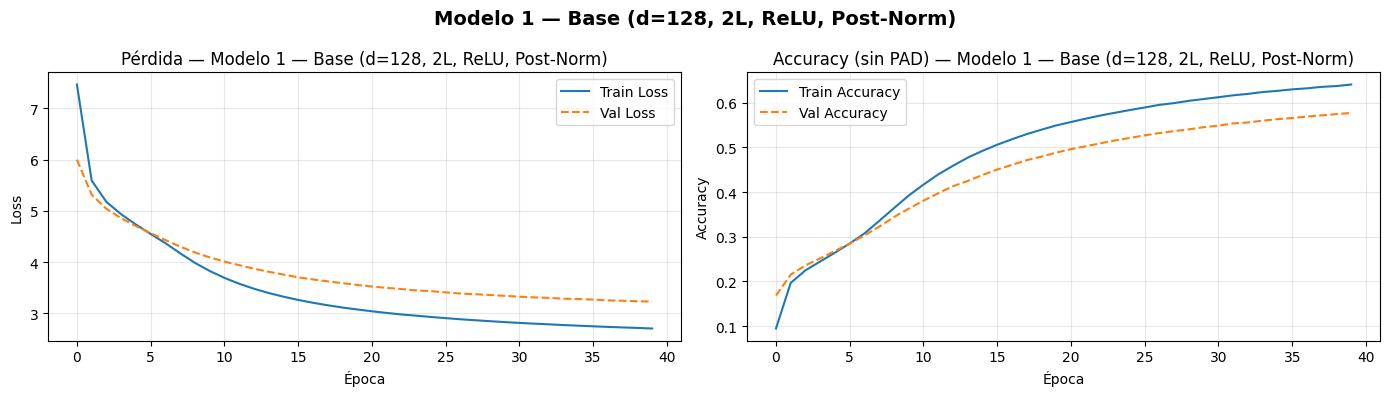

Brecha train-val (Modelo 1) → loss_gap: 0.5257 | acc_gap: 0.0635


In [ ]:
plot_history(hist1, title='Modelo 1 — Base (d=128, 2L, ReLU, Post-Norm)')
gap1 = overfitting_gap(hist1)
print(f"Brecha train-val (Modelo 1) → loss_gap: {gap1['loss_gap']:.4f} | acc_gap: {gap1['acc_gap']:.4f}")


**OBSERVACIÓN / ANÁLISIS:**

El Modelo 1 completó las 40 épocas sin que el early stopping lo detuviera, lo que indica que la pérdida de validación seguía mejorando lentamente al final, pero a bajo ritmo. Sus métricas finales son las más modestas de los tres experimentos: val_loss = 3.2 y val_accuracy = 0.57.

---

### Modelo 2 — Alta capacidad con regularización fuerte (d=256, 3 capas, GeLU, Post-Norm)

In [ ]:
np.random.seed(42); tf.random.set_seed(42)

modelo2 = TransformerModel(
    vocab_size=VOCAB_SIZE, d_model=256, num_heads=8, ff_dim=512,
    num_enc_layers=3, num_dec_layers=3, dropout_rate=0.30,
    activation='gelu', pre_norm=False, name='M2_AltaCapacidad_Regularizado'
)

lr_schedule2 = TransformerLRSchedule(d_model=256, warmup_steps=6000)
modelo2.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule2, weight_decay=1e-2,
        beta_1=0.9, beta_2=0.98, epsilon=1e-9, clipnorm=1.0
    ),
    loss=masked_label_smoothing_loss(smoothing=0.1),
    metrics=[masked_accuracy]
)

_ = modelo2([X_train_src[:2], train_dec_in[:2]], training=False)
modelo2.summary()

p1, p2 = modelo1.count_params(), modelo2.count_params()
print(f"\nParámetros M1: {p1:>12,}")
print(f"Parámetros M2: {p2:>12,}  ({p2/p1:.1f}x M1)")


Model: "M2_AltaCapacidad_Regularizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_emb (Embedding)             │ (2, 30, 256)           │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pos (PositionalEncoding)    │ (2, 30, 256)           │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_1                     │ ?                      │       527,104 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_2                     │ ?                      │       527,104 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_3                     │ ?                      │       527,104 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_emb (Embedding)             │ (2, 31, 256)           │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_pos (PositionalEncoding)    │ (2, 31, 256)           │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_block_1                     │ ?                      │       790,784 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_block_2                     │ ?                      │       790,784 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_block_3                     │ ?                      │       790,784 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_projection (Dense)       │ (2, 31, 10000)         │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,899,664 (45.39 MB)

 Trainable params: 11,643,664 (44.42 MB)

 Non-trainable params: 256,000 (1000.00 KB)


Parámetros M1:    4,640,528
Parámetros M2:   11,899,664  (2.6x M1)


In [ ]:
early_stop2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

hist2 = modelo2.fit(
    x=[X_train_src, train_dec_in], y=train_dec_out,
    batch_size=128, epochs=60,
    validation_data=([X_val_src, val_dec_in], val_dec_out),
    callbacks=[early_stop2], verbose=1
)
print(f"\n✓ Entrenamiento 2 completado. Épocas efectivas: {len(hist2.history['loss'])}")


Epoch 1/60
302/302 ━━━━━━━━━━━━━━━━━━━━ 128s 249ms/step - loss: 8.5549 - masked_accuracy: 0.0653 - val_loss: 7.4198 - val_masked_accuracy: 0.0865
Epoch 2/60
302/302 ━━━━━━━━━━━━━━━━━━━━ 78s 132ms/step - loss: 6.5757 - masked_accuracy: 0.1201 - val_loss: 6.0690 - val_masked_accuracy: 0.1664
Epoch 3/60
302/302 ━━━━━━━━━━━━━━━━━━━━ 37s 122ms/step - loss: 5.8620 - masked_accuracy: 0.1793 - val_loss: 5.6319 - val_masked_accuracy: 0.1939
Epoch 4/60
302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - loss: 5.5383 - masked_accuracy: 0.1980 - val_loss: 5.3869 - val_masked_accuracy: 0.2090
Epoch 5/60
302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - loss: 5.3257 - masked_accuracy: 0.2118 - val_loss: 5.2143 - val_masked_accuracy: 0.2220
Epoch 6/60
302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 126ms/step - loss: 5.1595 - masked_accuracy: 0.2244 - val_loss: 5.0771 - val_masked_accuracy: 0.2325
Epoch 7/60
302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - loss: 5.0253 - masked_accuracy: 0.2351 - val_loss: 4.9716 - val_masked_a

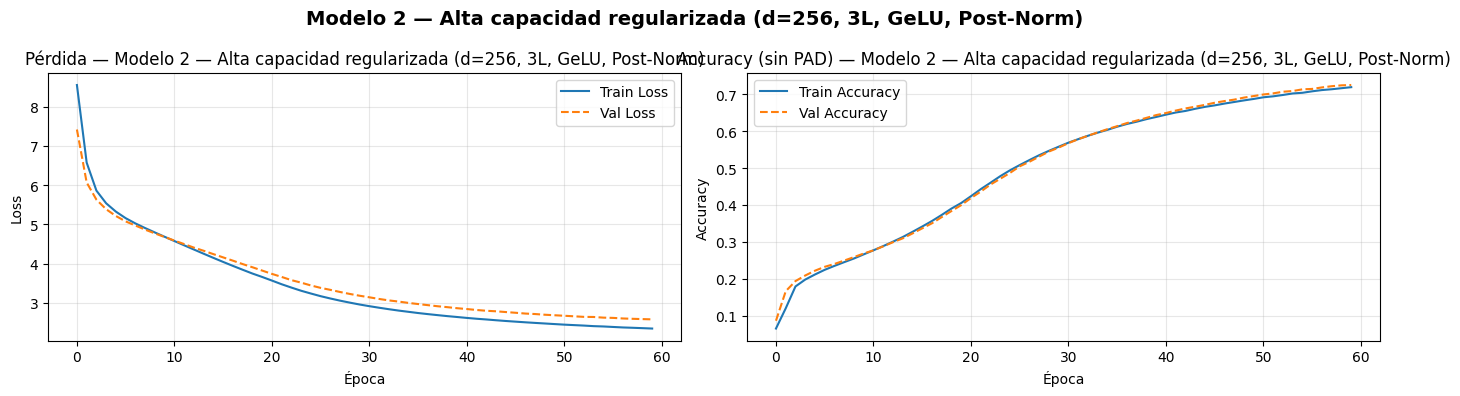

Brecha train-val (Modelo 2) → loss_gap: 0.2343 | acc_gap: -0.0058


In [ ]:
plot_history(hist2, title='Modelo 2 — Alta capacidad regularizada (d=256, 3L, GeLU, Post-Norm)')
gap2 = overfitting_gap(hist2)
print(f"Brecha train-val (Modelo 2) → loss_gap: {gap2['loss_gap']:.4f} | acc_gap: {gap2['acc_gap']:.4f}")


**OBSERVACIÓN / ANÁLISIS:**

A través del segundo modelo podemos observar como es que los cambios aplicados demuestran cambios en los resultados. En este caso, podemos visualizar como es que la pérdida y el accuracy en validación se mantiene mucho más ligado al entrenamiento, demostrando que posee una mejor capacidad de aprendizaje que el primer modelo, sin signos de overfitting.  Por otr lado, también se denotan valores más altos de accuracy, demostrando una mejor adaptabilidad y generalizaciòn del modelo.

---

### Modelo 3 — Final optimizado (Pre-Norm + GeLU + Label Smoothing)

In [ ]:
np.random.seed(42); tf.random.set_seed(42)

modelo3 = TransformerModel(
    vocab_size=VOCAB_SIZE, d_model=256, num_heads=8, ff_dim=512,
    num_enc_layers=3, num_dec_layers=3, dropout_rate=0.20,
    activation='gelu', pre_norm=True, name='M3_Final_PreNorm'
)

lr_schedule3 = TransformerLRSchedule(d_model=256, warmup_steps=6000)
modelo3.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule3, weight_decay=5e-3,
        beta_1=0.9, beta_2=0.98, epsilon=1e-9, clipnorm=1.0
    ),
    loss=masked_label_smoothing_loss(smoothing=0.1),
    metrics=[masked_accuracy]
)

_ = modelo3([X_train_src[:2], train_dec_in[:2]], training=False)
modelo3.summary()
print(f"\nParámetros M3: {modelo3.count_params():>12,}  ({modelo3.count_params()/p1:.1f}x M1)")


Model: "M3_Final_PreNorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_emb (Embedding)             │ (2, 30, 256)           │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pos (PositionalEncoding)    │ (2, 30, 256)           │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_1                     │ ?                      │       527,104 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_2                     │ ?                      │       527,104 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_3                     │ ?                      │       527,104 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_emb (Embedding)             │ (2, 31, 256)           │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_pos (PositionalEncoding)    │ (2, 31, 256)           │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_block_1                     │ ?                      │       790,784 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_block_2                     │ ?                      │       790,784 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_block_3                     │ ?                      │       790,784 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_40          │ (2, 31, 256)           │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_projection (Dense)       │ (2, 31, 10000)         │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,900,176 (45.40 MB)

 Trainable params: 11,644,176 (44.42 MB)

 Non-trainable params: 256,000 (1000.00 KB)


Parámetros M3:   11,900,176  (2.6x M1)


In [ ]:
early_stop3 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

hist3 = modelo3.fit(
    x=[X_train_src, train_dec_in], y=train_dec_out,
    batch_size=128, epochs=70,
    validation_data=([X_val_src, val_dec_in], val_dec_out),
    callbacks=[early_stop3], verbose=1
)
print(f"\n✓ Entrenamiento 3 completado. Épocas efectivas: {len(hist3.history['loss'])}")


Epoch 1/70
302/302 ━━━━━━━━━━━━━━━━━━━━ 136s 259ms/step - loss: 8.5024 - masked_accuracy: 0.0675 - val_loss: 7.3783 - val_masked_accuracy: 0.0865
Epoch 2/70
302/302 ━━━━━━━━━━━━━━━━━━━━ 39s 130ms/step - loss: 6.5183 - masked_accuracy: 0.1256 - val_loss: 6.0084 - val_masked_accuracy: 0.1717
Epoch 3/70
302/302 ━━━━━━━━━━━━━━━━━━━━ 37s 123ms/step - loss: 5.7863 - masked_accuracy: 0.1843 - val_loss: 5.5712 - val_masked_accuracy: 0.1971
Epoch 4/70
302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 126ms/step - loss: 5.4662 - masked_accuracy: 0.2039 - val_loss: 5.3368 - val_masked_accuracy: 0.2136
Epoch 5/70
302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 126ms/step - loss: 5.2590 - masked_accuracy: 0.2187 - val_loss: 5.1673 - val_masked_accuracy: 0.2257
Epoch 6/70
302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 126ms/step - loss: 5.0965 - masked_accuracy: 0.2307 - val_loss: 5.0367 - val_masked_accuracy: 0.2350
Epoch 7/70
302/302 ━━━━━━━━━━━━━━━━━━━━ 39s 128ms/step - loss: 4.9594 - masked_accuracy: 0.2426 - val_loss: 4.9224 - val_masked_a

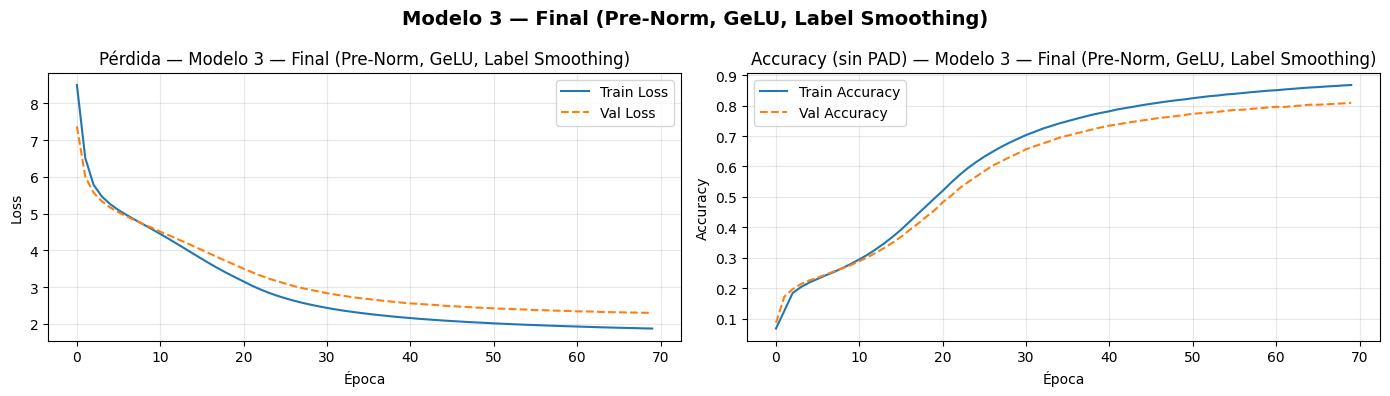

Brecha train-val (Modelo 3) → loss_gap: 0.4275 | acc_gap: 0.0584


In [ ]:
plot_history(hist3, title='Modelo 3 — Final (Pre-Norm, GeLU, Label Smoothing)')
gap3 = overfitting_gap(hist3)
print(f"Brecha train-val (Modelo 3) → loss_gap: {gap3['loss_gap']:.4f} | acc_gap: {gap3['acc_gap']:.4f}")


**OBSERVACIÓN / ANÁLISIS:**

A través de la visualización de los gráficos podemos comprender que la combinación de regularizadores en conjunto con pre-norm lograron mejorar el rendimiento del modelo. En este caso, se nota cierta separaciòn entre los valores de entrenamiento con los de validaciòn, aunque se demuestren buenos resultados de igual forma.

Se denotan mejoras en los resultados a comparaciòn de los modelos anteriores. donde la pérdida en validaciòn se mantiene por debajo del 3% y el accuracy se mantiene cerca del 80%.

### Comparación de la brecha train-val (overfitting) entre los tres modelos

In [ ]:
print(f"{'Modelo':<35} {'Parámetros':>14} {'Épocas':>8} {'loss_gap':>10} {'acc_gap':>10}")
print("-"*82)
for nombre, modelo, hist, gap in [
    ('M1 — Base',                      modelo1, hist1, gap1),
    ('M2 — Alta capacidad regularizada', modelo2, hist2, gap2),
    ('M3 — Final (Pre-Norm)',           modelo3, hist3, gap3),
]:
    print(f"{nombre:<35} {modelo.count_params():>14,} {len(hist.history['loss']):>8} "
          f"{gap['loss_gap']:>10.4f} {gap['acc_gap']:>10.4f}")


Modelo                                  Parámetros   Épocas   loss_gap    acc_gap
----------------------------------------------------------------------------------
M1 — Base                                4,640,528       40     0.5257     0.0635
M2 — Alta capacidad regularizada        11,899,664       60     0.2343    -0.0058
M3 — Final (Pre-Norm)                   11,900,176       70     0.4275     0.0584


A partir de la tabla podemos comprender como es que cada modelo obtuvo diferentes resultados en relación a lo que son las brechas entre entrenamiento y validación. En este caso, podemos comprender como es que el segundo modelo ubtuvo la brecha más pequeña, pero debemos tener presente que a la hora de querer comparar los resultados del modelo debemos tomar en cuenta su capacidad de generación. En este caso, es preferible hacer una comparación de generación entre los tres modelos para comprender resultados visuales.

## 7. Generación de Texto

In [ ]:
def generate_text(model, seed_text, word_to_idx, idx_to_word,
                  max_gen=30, temperature=1.0):
    """Generación auto-regresiva con muestreo por temperatura."""
    seed_words  = seed_text.lower().split()
    src_ids     = [word_to_idx.get(w, UNK_IDX) for w in seed_words[-SRC_LEN:]]
    src_ids     = src_ids + [PAD_IDX] * (SRC_LEN - len(src_ids))
    src         = np.array([src_ids], dtype=np.int32)
    dec_tokens  = [START_IDX]
    generated   = []

    for _ in range(max_gen):
        dec_in  = np.array([dec_tokens], dtype=np.int32)
        logits  = model([src, dec_in], training=False)
        logits  = logits[0, -1, :].numpy() / max(temperature, 1e-8)
        probs   = np.exp(logits - np.max(logits))
        probs  /= probs.sum()
        next_token = int(np.random.choice(len(probs), p=probs))
        if next_token == END_IDX:
            break
        generated.append(next_token)
        dec_tokens.append(next_token)

    words_gen = [idx_to_word.get(i, UNK_TOKEN) for i in generated
                 if i not in (PAD_IDX, START_IDX, END_IDX)]
    return ' '.join(words_gen)


def generate_nucleus(model, seed_text, word_to_idx, idx_to_word,
                     max_gen=30, top_p=0.9):
    """
    Nucleus Sampling (Top-P) — Holtzman et al., 2019.

    Filtra el vocabulario al núcleo de tokens cuya probabilidad acumulada
    alcanza 'top_p'. Evita repetición (greedy puro) y ruido (sampling con toda la distribución).
    """
    seed_words  = seed_text.lower().split()
    src_ids     = [word_to_idx.get(w, UNK_IDX) for w in seed_words[-SRC_LEN:]]
    src_ids     = src_ids + [PAD_IDX] * (SRC_LEN - len(src_ids))
    src         = np.array([src_ids], dtype=np.int32)
    dec_tokens  = [START_IDX]
    generated   = []

    for _ in range(max_gen):
        dec_in = np.array([dec_tokens], dtype=np.int32)
        logits = model([src, dec_in], training=False)
        logits = logits[0, -1, :].numpy()
        probs  = np.exp(logits - np.max(logits))
        probs /= probs.sum()

        sorted_idx  = np.argsort(probs)[::-1]
        sorted_prob = probs[sorted_idx]
        cum_prob    = np.cumsum(sorted_prob)

        nucleus_mask = cum_prob <= top_p
        nucleus_mask[0] = True
        nucleus_idx  = sorted_idx[nucleus_mask]
        nucleus_prob = probs[nucleus_idx]
        nucleus_prob /= nucleus_prob.sum()

        next_token = int(np.random.choice(nucleus_idx, p=nucleus_prob))
        if next_token == END_IDX:
            break
        generated.append(next_token)
        dec_tokens.append(next_token)

    words_gen = [idx_to_word.get(i, UNK_TOKEN) for i in generated
                 if i not in (PAD_IDX, START_IDX, END_IDX)]
    return ' '.join(words_gen)


seeds = [
    "en un lugar de la mancha de cuyo nombre no quiero acordarme",
    "don quijote de la mancha caballero andante",
    "sancho panza respondió con mucha humildad y dijo"
]

print("=" * 70)
print("GENERACIÓN DE TEXTO — Modelo 3 (Final)")
print("=" * 70)
for seed in seeds:
    print(f"\n▶ SEMILLA: {seed}")
    for temp, label in [(0.7, 'conservador'), (1.0, 'estándar'), (1.3, 'creativo')]:
        gen = generate_text(modelo3, seed, word_to_idx, idx_to_word,
                            max_gen=25, temperature=temp)
        print(f"  [temp={temp} {label:13s}]  {gen}")
    for p in [0.9, 0.95]:
        gen = generate_nucleus(modelo3, seed, word_to_idx, idx_to_word,
                               max_gen=25, top_p=p)
        print(f"  [nucleus p={p}          ]  {gen}")


GENERACIÓN DE TEXTO — Modelo 3 (Final)

▶ SEMILLA: en un lugar de la mancha de cuyo nombre no quiero acordarme
  [temp=0.7 conservador  ]  . con esto se <UNK> las <UNK> , y , por conjeturas sus deseos , se vuelven a alegrar , y , aunque no es
  [temp=1.0 estándar     ]  . con esto se <UNK> las <UNK> , proseguía servirse sus cabellos , y así , oreja que cumplía todas ; antes , estando más
  [temp=1.3 creativo     ]  entretuviese fresco grabada lleguen cortesano peligro , y <UNK> sus labios ; curaban cuita de sus cabellos honestas , traerte particularmente quien , edificios impiden
  [nucleus p=0.9          ]  . con esto , señor , no hay para salud ; si se , las <UNK> , las <UNK> en las páramos desiertos , de
  [nucleus p=0.95          ]  . con esto se retiraron de la fermosas , y , por dioses que en su demanda acabó amores , hecimos toda la hacienda ,

▶ SEMILLA: don quijote de la mancha caballero andante
  [temp=0.7 conservador  ]  ; y si no , las <UNK> , las hay , las <UNK> que quisie

### 7.1 Análisis Crítico de la Calidad de Generación

In [ ]:
def analisis_generacion(model, test_src, test_dec_out, idx_to_word,
                        num_samples=50, temperatura=0.8):
    """
    Evalúa cualitativamente el texto generado:
    - Tasa de tokens UNK
    - Longitud promedio de secuencias generadas
    - Diversidad léxica (palabras únicas / total)
    """
    total_tokens = 0
    unk_tokens   = 0
    all_words    = []
    generaciones = []

    for i in range(num_samples):
        seed_words = [idx_to_word.get(int(t), '<UNK>') for t in test_src[i]
                      if int(t) not in (PAD_IDX,)]
        seed_text  = ' '.join(seed_words)
        gen        = generate_text(model, seed_text, word_to_idx, idx_to_word,
                                   max_gen=TGT_LEN, temperature=temperatura)
        gen_words  = gen.split()
        total_tokens += len(gen_words)
        unk_tokens   += gen_words.count('<UNK>')
        all_words.extend(gen_words)

        ref_ids   = test_dec_out[i]
        ref_words = [idx_to_word.get(int(t), '<UNK>') for t in ref_ids
                     if int(t) not in (PAD_IDX, START_IDX, END_IDX)]
        if i < 5:
            generaciones.append({
                'semilla':    ' '.join(seed_words[-10:]),
                'generado':   gen,
                'referencia': ' '.join(ref_words)
            })

    tasa_unk    = unk_tokens / max(total_tokens, 1)
    longitud_pm = total_tokens / num_samples
    diversidad  = len(set(w for w in all_words if w != '<UNK>')) / max(total_tokens, 1)
    return {'tasa_unk': tasa_unk, 'longitud_pm': longitud_pm,
            'diversidad': diversidad, 'ejemplos': generaciones}

print("Analizando calidad de generación de los 3 modelos...")
analisis1 = analisis_generacion(modelo1, X_test_src, test_dec_out, idx_to_word, num_samples=50)
analisis2 = analisis_generacion(modelo2, X_test_src, test_dec_out, idx_to_word, num_samples=50)
analisis3 = analisis_generacion(modelo3, X_test_src, test_dec_out, idx_to_word, num_samples=50)

print(f"\n{'='*60}")
print(f"{'Métrica cualitativa':<30} {'M1':>8} {'M2':>8} {'M3★':>8}")
print(f"{'='*60}")
print(f"{'Tasa tokens <UNK> (%)':<30} "
      f"{analisis1['tasa_unk']*100:>7.1f}% "
      f"{analisis2['tasa_unk']*100:>7.1f}% "
      f"{analisis3['tasa_unk']*100:>7.1f}%")
print(f"{'Longitud promedio (tokens)':<30} "
      f"{analisis1['longitud_pm']:>8.1f} "
      f"{analisis2['longitud_pm']:>8.1f} "
      f"{analisis3['longitud_pm']:>8.1f}")
print(f"{'Diversidad léxica (%)':<30} "
      f"{analisis1['diversidad']*100:>7.1f}% "
      f"{analisis2['diversidad']*100:>7.1f}% "
      f"{analisis3['diversidad']*100:>7.1f}%")
print(f"{'='*60}")


Analizando calidad de generación de los 3 modelos...

Métrica cualitativa                  M1       M2      M3★
Tasa tokens <UNK> (%)              3.1%     2.3%     3.2%
Longitud promedio (tokens)         30.0     30.0     30.0
Diversidad léxica (%)             34.1%    32.3%    32.4%


Se puede denotra a través de las métricas que los tres modelos poseen una cantidad igual de baja en base a lo que es la tasa de UNK. No denotando un problema estructural, pero si como ruido puntual.

La longitud promedio nos permite comprender que ninguno de los tres modelos tuvo problemas de consistencia, demostrando que todos alcanzaron la longitud máxima.

Los tres modelos comprenden una diversidad léxica algo similar. Que el primer modelo posea un valor mayor en comparación a los otros modelos no necesariamente indica que tiene mayor diversidad, pero que probablemente es mucho más propensa a usar palabras sin coherencia al generar texto.

In [ ]:
print(f"\n{'='*65}")
print(f"EJEMPLOS — Modelo 3 — Semilla / Generación / Referencia")
print(f"{'='*65}")
for j, ej in enumerate(analisis3['ejemplos']):
    print(f"\n── Ejemplo {j+1} ──")
    print(f"  SEMILLA:     ...{ej['semilla']}")
    print(f"  GENERADO:    {ej['generado']}")
    print(f"  REFERENCIA:  {ej['referencia']}")

seed_fixed = "don quijote respondió con gravedad y dijo a sancho"
print(f"\n{'='*65}")
print(f"TEMPERATURA vs NUCLEUS SAMPLING — Modelo 3")
print(f"Semilla: '{seed_fixed}'")
print(f"{'='*65}")
for t in [0.7, 1.0, 1.3]:
    gen = generate_text(modelo3, seed_fixed, word_to_idx, idx_to_word, max_gen=20, temperature=t)
    print(f"  temp={t}:         {gen}")
for p in [0.85, 0.9, 0.95]:
    gen = generate_nucleus(modelo3, seed_fixed, word_to_idx, idx_to_word, max_gen=20, top_p=p)
    print(f"  nucleus p={p}: {gen}")



EJEMPLOS — Modelo 3 — Semilla / Generación / Referencia

── Ejemplo 1 ──
  SEMILLA:     ...diablo para diablo y el temor para mezquino ; que
  GENERADO:    , como tengo dicho , es bien para más mal rolliza y tiraba de <UNK> , acorrer a los necesitados precisa de las <UNK> que a los mares de cosarios
  REFERENCIA:  un buen corazón <UNK> mala ventura , como vos bien sabéis . a estas razones respondió con éstas disparatadas sancho , que , hablando con merlín , le preguntó :

── Ejemplo 2 ──
  SEMILLA:     .... - muchos médicos hay en el mundo : hasta
  GENERADO:    esto hay volvérsela a quien se me ha hecho ; pero , aunque yo no me lo veo , digo , pues , aunque me lo volverla con su ser
  REFERENCIA:  los encantadores son médicos - replicó sancho - ; pero , pues todos me lo dicen , aunque yo no me lo veo , digo que soy contento de darme

── Ejemplo 3 ──
  SEMILLA:     ..., me dieron muchos mojicones y porrazos , sin saber
  GENERADO:    qué es cosa de transformación . - no satisfará acue

### Interpretación de Aciertos y Errores

**Aciertos:**
*   Coherencia sintáctica: el texto generado mantiene una estructura gramatical correcta del español: concordancia básica, uso adecuado de signos de puntuación y la estructura de diálogo con guión ("- dijo sancho -" por ejemplo). No produce secuencias agramaticales en las temperaturas bajas/medias.
*   Estilo: reproduce con fidelidad el estilo base de la escritura dedicada al texto (formas como *"díganme"*, *"fermosas"*, etc.), por lo que el vocabulario generado es estilísticamente muy similar al del texto original.
*   Tasa de "<UNK>" razonable: en M3 es de 3.2 %, valor bajo y consistente con la cobertura del vocabulario de 10.000 palabras (96.8 %). Los "<UNK>" aparecen,pero no dominan el texto.

**Errores:**

*   Deriva semántica: el contenido generado se aleja del de la referencia. Esto es esperable en generación abierta: el modelo produce una continuación "plausible", no la continuación exacta del libro, por lo que BLEU/ROUGE (que miden solapamiento con la referencia) nunca serán perfectos.
*   Repeticiones: se observa un patrón recurrente del tipo "las <UNK> , las <UNK>", donde el modelo cae en bucles cortos, sobre todo con muestreo conservador.
*   Degradación con temperatura alta: a "temp=1.3" el texto pierde coherencia y se vuelve una sucesión de palabras sueltas inconexas, mientras que "temp=0.7" y *nucleus p=0.9* entregan los pasajes más legibles.
*   Relación con las métricas cuantitativas: la diversidad léxica (32.4%) es moderada y la longitud (30 tokens) está fijada por "max_gen". Una tasa de "<UNK>" baja junto a diversidad moderada explica un texto legible pero con algo de relleno, lo que es coherente con los valores intermedios de BLEU/ROUGE (solapamiento parcial con la referencia, no total).




## 8. Evaluación con Métricas NLP

### Decisión de eficiencia: Greedy Decoding en vez de Beam Search

Beam Search re-evalúa el modelo
`beam_width` veces en cada paso de generación (y además ordena/filtra candidatos), lo que para
`beam_width=6` significa aproximadamente **6 veces más forward-passes** que una generación de una
sola hipótesis por paso.

Por eso, la evaluación cuantitativa de los tres modelos se hace con **Greedy Decoding** (se toma en
cada paso el token de mayor probabilidad, `argmax`), que:

- Genera una sola hipótesis por ejemplo (sin mantener ni comparar múltiples beams).
- Es determinístico y reproducible.
- Reduce el tiempo de evaluación de horas a minutos para el mismo número de muestras de test.

La función `beam_search` se conserva más abajo solo como referencia opcional,
por si se quiere comparar greedy vs beam en una muestra pequeña; no se usa para evaluar los tres
modelos completos.

In [ ]:
def greedy_decode(model, src, max_len=35):
    """
    Decodificación Greedy: en cada paso se elige el token de mayor probabilidad (argmax).
    Una sola hipótesis por ejemplo -> O(max_len) forward-passes, mucho más rápido que Beam Search.
    """
    dec_tokens = [START_IDX]
    for _ in range(max_len):
        dec_in = np.array([dec_tokens], dtype=np.int32)
        logits = model([src, dec_in], training=False)
        next_token = int(tf.argmax(logits[0, -1, :]).numpy())
        if next_token == END_IDX:
            break
        dec_tokens.append(next_token)
    return [t for t in dec_tokens[1:] if t not in (END_IDX, PAD_IDX, START_IDX)]


def evaluate_bleu_rouge(model, test_src, test_dec_out,
                        idx_to_word, num_samples=200):
    """Evalúa BLEU (corpus) y ROUGE (promedio) usando Greedy Decoding."""
    references_bleu = []
    hypotheses_bleu = []
    r1_scores, r2_scores, rL_scores = [], [], []
    scorer_rouge = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'], use_stemmer=False
    )
    num_samples = min(num_samples, len(test_src))

    for i in range(num_samples):
        src       = test_src[i:i+1]
        ref_ids   = test_dec_out[i]
        ref_words = [idx_to_word.get(int(t), UNK_TOKEN) for t in ref_ids
                     if int(t) not in (PAD_IDX, START_IDX, END_IDX)]
        hyp_ids   = greedy_decode(model, src, max_len=TGT_LEN+2)
        hyp_words = [idx_to_word.get(t, UNK_TOKEN) for t in hyp_ids]
        if not ref_words or not hyp_words:
            continue
        references_bleu.append([ref_words])
        hypotheses_bleu.append(hyp_words)
        sc = scorer_rouge.score(' '.join(ref_words), ' '.join(hyp_words))
        r1_scores.append(sc['rouge1'].fmeasure)
        r2_scores.append(sc['rouge2'].fmeasure)
        rL_scores.append(sc['rougeL'].fmeasure)

    bleu1 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(1,0,0,0))
    bleu2 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(.5,.5,0,0))
    bleu4 = corpus_bleu(references_bleu, hypotheses_bleu)
    return {
        'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-4': bleu4,
        'ROUGE-1': float(np.mean(r1_scores)),
        'ROUGE-2': float(np.mean(r2_scores)),
        'ROUGE-L': float(np.mean(rL_scores))
    }

print("✓ Greedy Decoding y evaluación BLEU/ROUGE definidos")


✓ Greedy Decoding y evaluación BLEU/ROUGE definidos


### 8.1 Beam Search con normalización por longitud

Se mantiene disponible esta función por completitud y para quien quiera comparar greedy vs beam en
una muestra pequeña, pero **no se ejecuta sobre los 200 ejemplos de test** para no incurrir en el
alto costo computacional reportado al usar los 4 modelos anteriores.

In [ ]:
def beam_search(model, src, beam_width=4, max_len=35, alpha=0.6):
    """
    Beam Search con normalización por longitud (Wu et al., 2016).
    Disponible como referencia opcional — no se usa en la evaluación principal (ver sección 8).
    """
    beams     = [(0.0, [START_IDX])]
    completed = []

    for _ in range(max_len):
        all_candidates = []
        for log_prob, tokens in beams:
            if tokens[-1] == END_IDX:
                completed.append((log_prob, tokens))
                continue
            dec_in  = np.array([tokens], dtype=np.int32)
            logits  = model([src, dec_in], training=False)
            log_p   = tf.nn.log_softmax(logits[0, -1, :]).numpy()
            top_k   = np.argsort(log_p)[-beam_width:]
            for tok in top_k:
                all_candidates.append((log_prob + log_p[tok], tokens + [int(tok)]))

        if not all_candidates:
            break

        def length_norm(x):
            log_p, toks = x
            lp = ((5 + len(toks)) / 6.0) ** alpha
            return log_p / lp

        all_candidates.sort(key=length_norm, reverse=True)
        beams = all_candidates[:beam_width]
        if all(t[-1] == END_IDX for _, t in beams):
            completed.extend(beams)
            break

    completed.extend(beams)
    if not completed:
        return []
    best   = max(completed, key=lambda x: x[0] / max(((5 + len(x[1])) / 6.0) ** alpha, 1))
    tokens = best[1]
    return [t for t in tokens[1:] if t not in (END_IDX, PAD_IDX, START_IDX)]

# Ejemplo de comparación greedy vs beam en una muestra pequeña (opcional)
N_DEMO = 5
print(f"Comparación Greedy vs Beam Search en {N_DEMO} ejemplos (solo demostrativo):")
for i in range(N_DEMO):
    src = X_test_src[i:i+1]
    g   = ' '.join(idx_to_word.get(t, UNK_TOKEN) for t in greedy_decode(modelo3, src, max_len=TGT_LEN+2))
    b   = ' '.join(idx_to_word.get(t, UNK_TOKEN) for t in beam_search(modelo3, src, beam_width=4, max_len=TGT_LEN+2))
    print(f"\n[{i}] greedy: {g}")
    print(f"[{i}] beam:   {b}")


Comparación Greedy vs Beam Search en 5 ejemplos (solo demostrativo):

[0] greedy: , como vos decís , señor , bien tantas estas cosas éstas son las que aquí traigo , quizá los <UNK> y <UNK> con merlín , le preguntó : -
[0] beam:   , como vos ahora no tenéis oficio ni beneficio . - ¿ qué decís entre vos , sancho ? ¿ qué es lo que hacen y otras mayores ? pasaba

[1] greedy: yo te hago de los encantadores que me persiguen , aunque , aunque todos me lo sabes . - yo no me lo digo - respondió don quijote - ,
[1] beam:   yo soy hecho de los encantadores : yo soy muy <UNK> , pues no me puedo persuadir , aunque yo no me lo haya mandado ; mas , con todo

[2] greedy: qué cara me llevan . y , sin duda alguna , a lo que parece , tengo por aquí esta cabeza que se tengo de <UNK> en los huesos de
[2] beam:   por vida de mis padres . - ¡ aquí de mi padre ! - dijo el del bosque - , y por ahora que se vee ver la cabeza que

[3] greedy: siempre es el deseo de alcanzar fama y la <UNK> , porque en las simple

In [ ]:
print("Evaluando los 3 modelos con Greedy Decoding...")

metricas1 = evaluate_bleu_rouge(modelo1, X_test_src, test_dec_out, idx_to_word, num_samples=200)
print("✓ Modelo 1 evaluado")

metricas2 = evaluate_bleu_rouge(modelo2, X_test_src, test_dec_out, idx_to_word, num_samples=200)
print("✓ Modelo 2 evaluado")

metricas3 = evaluate_bleu_rouge(modelo3, X_test_src, test_dec_out, idx_to_word, num_samples=200)
print("✓ Modelo 3 evaluado")

print("\n✓ Evaluación completa de los 3 modelos.")


Evaluando los 3 modelos con Greedy Decoding...
✓ Modelo 1 evaluado
✓ Modelo 2 evaluado
✓ Modelo 3 evaluado

✓ Evaluación completa de los 3 modelos.


In [ ]:
# ── Tabla comparativa de métricas ────────────────────────────────────────────
print("\n" + "=" * 64)
print(f"{'Métrica':<12} {'M1 (Base)':>14} {'M2 (Regular.)':>15} {'M3★ (Final)':>14}")
print("=" * 64)
for k in ['BLEU-1', 'BLEU-2', 'BLEU-4', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']:
    vals = [metricas1[k], metricas2[k], metricas3[k]]
    best = max(range(3), key=lambda i: vals[i])
    row  = f"{k:<12}"
    for i, v in enumerate(vals):
        marker = " ◀" if i == best else "  "
        row += f" {v:>12.4f}{marker}"
    print(row)
print("=" * 64)
print("◀ indica el mejor resultado en esa métrica")



Métrica           M1 (Base)   M2 (Regular.)    M3★ (Final)
BLEU-1             0.3648         0.4498         0.4767 ◀
BLEU-2             0.2074         0.3258         0.3519 ◀
BLEU-4             0.1005         0.2273         0.2580 ◀
ROUGE-1            0.3185         0.4105         0.4407 ◀
ROUGE-2            0.0964         0.2186         0.2444 ◀
ROUGE-L            0.2454         0.3463         0.3729 ◀
◀ indica el mejor resultado en esa métrica


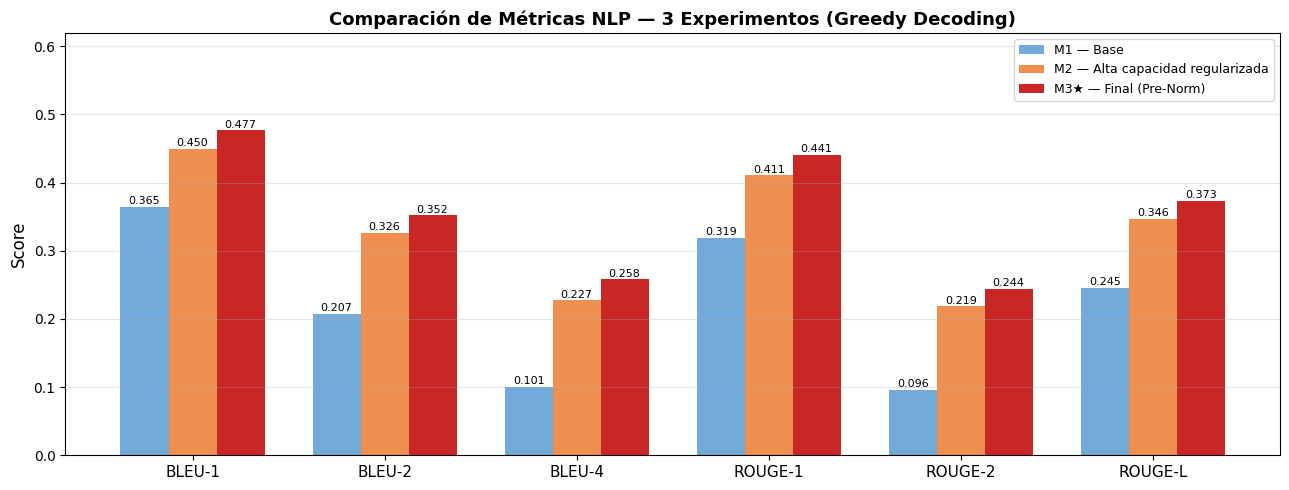

In [ ]:
# ── Gráfico comparativo 3 modelos ────────────────────────────────────────────
keys   = ['BLEU-1', 'BLEU-2', 'BLEU-4', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
vals   = [[metricas1[k] for k in keys],
          [metricas2[k] for k in keys],
          [metricas3[k] for k in keys]]
labels = ['M1 — Base', 'M2 — Alta capacidad regularizada', 'M3★ — Final (Pre-Norm)']
colors = ['#5B9BD5', '#ED7D31', '#C00000']
x, w   = np.arange(len(keys)), 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (v, lbl, clr) in enumerate(zip(vals, labels, colors)):
    bars = ax.bar(x + (i-1)*w, v, w, label=lbl, color=clr, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparación de Métricas NLP — 3 Experimentos (Greedy Decoding)', fontsize=13,
             fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(keys, fontsize=11)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(v) for v in vals) * 1.30)
plt.tight_layout(); plt.show()


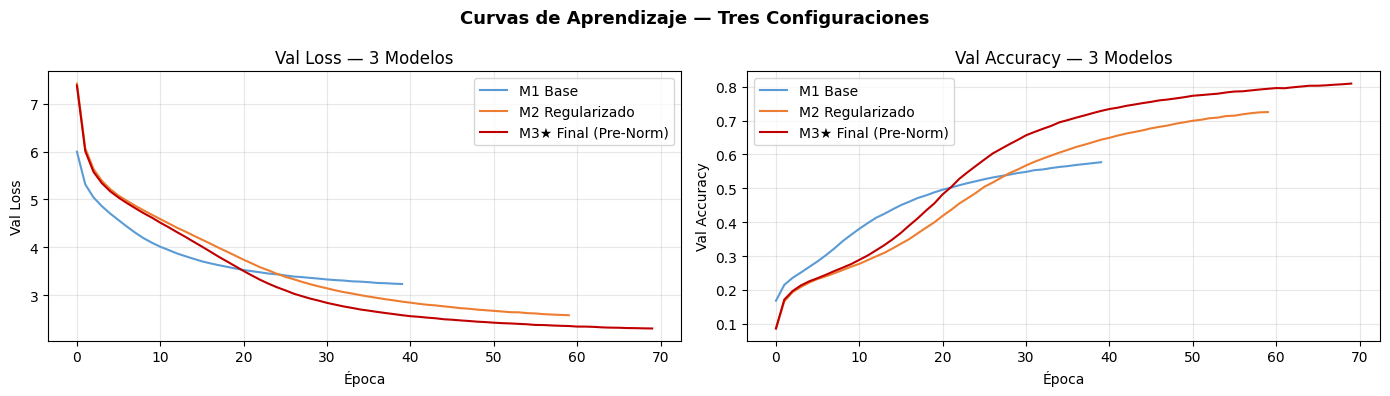

In [ ]:
# ── Curvas de aprendizaje — 3 modelos ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cfgs = [
    (hist1, '#5B9BD5', 'M1 Base'),
    (hist2, '#ED7D31', 'M2 Regularizado'),
    (hist3, '#C00000', 'M3★ Final (Pre-Norm)'),
]

for h, clr, lbl in cfgs:
    axes[0].plot(h.history['val_loss'],           label=lbl, color=clr)
    axes[1].plot(h.history['val_masked_accuracy'], label=lbl, color=clr)

axes[0].set_title('Val Loss — 3 Modelos'); axes[0].set_xlabel('Época')
axes[0].set_ylabel('Val Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Val Accuracy — 3 Modelos'); axes[1].set_xlabel('Época')
axes[1].set_ylabel('Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Curvas de Aprendizaje — Tres Configuraciones', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9. Análisis Comparativo de los Tres Experimentos

In [ ]:
def last_val(h, key):
    return h.history[key][-1]

print("=" * 88)
print("RESUMEN COMPARATIVO — 3 EXPERIMENTOS (v6)")
print("=" * 88)
print(f"{'Hiperparámetro':<35} {'M1 (Base)':>14} {'M2 (Regular.)':>14} {'M3★ (Final)':>14}")
print("-" * 88)
for row in [
    ('d_model',                '128',   '256',   '256'),
    ('num_heads',               '4',     '8',     '8'),
    ('ff_dim',                  '256',   '512',   '512'),
    ('num_enc/dec_layers',      '2/2',   '3/3',   '3/3'),
    ('dropout_rate',            '0.10',  '0.30',  '0.20'),
    ('activación FFN',          'ReLU',  'GeLU',  'GeLU'),
    ('normalización',           'Post',  'Post',  'Pre-Norm'),
    ('weight_decay (AdamW)',    '1e-4',  '1e-2',  '5e-3'),
    ('label_smoothing',         'eps=0.1','eps=0.1','eps=0.1'),
    ('gradient_clipping',       '1.0',   '1.0',   '1.0'),
    ('warmup_steps',            '4000',  '6000',  '6000'),
    ('batch_size',              '64',    '128',   '128'),
    ('max_epochs/patience',     '40/6',  '60/8',  '70/10'),
]:
    print(f"{row[0]:<35} {row[1]:>14} {row[2]:>14} {row[3]:>14}")

print("-" * 88)
e = [len(h.history['loss']) for h in [hist1, hist2, hist3]]
print(f"{'Épocas efectivas':<35} {e[0]:>14} {e[1]:>14} {e[2]:>14}")
ps = [m.count_params() for m in [modelo1, modelo2, modelo3]]
print(f"{'Parámetros totales':<35} " + " ".join(f"{p:>14,}" for p in ps))
print(f"{'Val Loss (final)':<35} "
      + " ".join(f"{last_val(h,'val_loss'):>14.4f}" for h in [hist1,hist2,hist3]))
print(f"{'Val Accuracy (final)':<35} "
      + " ".join(f"{last_val(h,'val_masked_accuracy'):>14.4f}" for h in [hist1,hist2,hist3]))
print(f"{'loss_gap (train-val)':<35} "
      + " ".join(f"{g['loss_gap']:>14.4f}" for g in [gap1,gap2,gap3]))
print(f"{'acc_gap (train-val)':<35} "
      + " ".join(f"{g['acc_gap']:>14.4f}" for g in [gap1,gap2,gap3]))
print(f"{'BLEU-4 (Greedy)':<35} "
      + " ".join(f"{m['BLEU-4']:>14.4f}" for m in [metricas1,metricas2,metricas3]))
print(f"{'ROUGE-L (Greedy)':<35} "
      + " ".join(f"{m['ROUGE-L']:>14.4f}" for m in [metricas1,metricas2,metricas3]))
print("=" * 88)


RESUMEN COMPARATIVO — 3 EXPERIMENTOS (v6)
Hiperparámetro                           M1 (Base)  M2 (Regular.)    M3★ (Final)
----------------------------------------------------------------------------------------
d_model                                        128            256            256
num_heads                                        4              8              8
ff_dim                                         256            512            512
num_enc/dec_layers                             2/2            3/3            3/3
dropout_rate                                  0.10           0.30           0.20
activación FFN                                ReLU           GeLU           GeLU
normalización                                 Post           Post       Pre-Norm
weight_decay (AdamW)                          1e-4           1e-2           5e-3
label_smoothing                            eps=0.1        eps=0.1        eps=0.1
gradient_clipping                              1.0         

### Análisis del Impacto de Cada Mejora

**Anáisis de selección del modelo final:**

**1. Brecha train-val y efecto de la regularización.**
El modelo con la mayor brecha es M1 (loss_gap=0.5257, acc_gap=0.0635), justamente la configuración con menos regularización (dropout=0.10, weight_decay=1e-4). Las medidas aplicadas sí redujeron la brecha: en M2 el dropout alto (0.30) y el weight_decay fuerte (1e-2) bajaron la loss_gap a = 0.2343 con un acc_gap negativo (-0.0058), es decir, casi sin overfitting. En M3 la brecha vuelve a subir (loss_gap=0.4275) porque se relajó deliberadamente la regularización (dropout=0.20) para ganar capacidad de ajuste, apoyándose en el Pre-Norm para la estabilidad.

**2. Mejor BLEU-4 / ROUGE-L.**
El mejor modelo en métricas de generaciòn es el M3 (BLEU-4=0.2580, ROUGE-L=0.3729), el cual gana en las seis métricas de la tabla (BLEU-1/2/4 y ROUGE-1/2/L). Esto no coincide con el modelo de menor brecha (que es M2). Conclusión importante: el mejor generalizador en términos de brecha train-val no es necesariamente el mejor en métricas de generación. M2 minimiza el overfitting, pero M3 logró mejor pérdida y accuracy absolutos y, con ello, mejor calidad de texto.

**3. Justificación del modelo final**
Se elige el **M3** como modelo final por la siguiente evidencia:
- **Mejores valores absolutos:** val_loss=2.3023 (la más baja) y val_accuracy=0.8091 (la más alta), además del mejor BLEU-4 y ROUGE-L.
- **Pre-Norm:** estabiliza los gradientes y permite entrenar con mayor profundidad y más épocas efectivas (70) sin divergir, algo que en arquitecturas Post-Norm profundas es más difícil.
- **Warmup (6000 steps):** evita la divergencia temprana al subir la tasa de aprendizaje de forma gradual, clave dado el tamaño del modelo.
- **Batch size (128):** entrega estimaciones de gradiente más estables que el batch=64 de M1, favoreciendo una optimización más suave.

El leve aumento de brecha de M3 respecto a M2 es un costo aceptable, porque se traduce directamente en mejor calidad de generación, que es el objetivo de la tarea.

## 10. Comparativa: LSTM (Entregable 3.1) vs Transformer
Esta sección evalúa la capacidad de explicar las diferencias entre arquitecturas tradicionales (RNN/LSTM) y Transformers.

### Diferencias Conceptuales

| Aspecto | LSTM (Entregable 3.1) | Transformer (Entregable 3.2) |
|---|---|---|
| **Tokenización** | Nivel de carácter | Nivel de palabra |
| **Procesamiento** | Secuencial (paso a paso) | Paralelo (toda la secuencia) |
| **Memoria** | Estado oculto h_t (cuello de botella) | Atención directa entre tokens |
| **Dependencias largas** | Se degradan con la distancia | Capturadas en O(1) vía atención |
| **Complejidad temporal** | O(n) por secuencia | O(n²) en atención, pero paralelizable |
| **Posición** | Implícita (orden de procesamiento) | Explícita (Positional Encoding) |
| **Escalabilidad GPU** | Limitada (estado secuencial) | Excelente (operaciones matriciales en paralelo) |
| **Métricas usadas** | Accuracy, F1-score | BLEU, ROUGE |
| **Generación** | Muestreo por temperatura | Temperatura + Nucleus Sampling |
| **Decodificación evaluada** | — | Greedy (eficiente) |

### ¿Por qué el Transformer suele superar al LSTM en tareas de NLP?

1. **Atención directa:** Self-attention conecta directamente cualquier par de tokens sin importar
   la distancia entre ellos. El LSTM debe "recordar" información a través de muchos pasos de tiempo,
   lo que degrada las dependencias largas.

2. **Paralelismo:** El Transformer procesa todos los tokens simultáneamente durante el
   entrenamiento, aprovechando eficientemente GPUs/TPUs. El LSTM es inherentemente secuencial
   (cada paso depende del anterior), lo que limita su velocidad de entrenamiento.

3. **Escalabilidad:** Los Transformers escalan mejor con más datos y parámetros, lo que explica
   por qué son la base de modelos como GPT, BERT y T5.

4. **Pre-Norm (M3 de este notebook):** mejora adicional sobre la arquitectura original del paper
   que favorece mayor profundidad y estabilidad en el entrenamiento.

### Cuándo preferir LSTM sobre Transformer

- **Datos muy escasos** (corpus pequeños): el Transformer, al tener más parámetros, tiende a
  sobreajustarse con más facilidad si no se regulariza adecuadamente (ver sección 9).
- **Secuencias en streaming** (p. ej. audio en tiempo real): el procesamiento secuencial del LSTM
  es una ventaja cuando no se dispone de toda la secuencia de antemano.
- **Recursos limitados** (dispositivos edge): los LSTMs son habitualmente más livianos en
  inferencia que un Transformer con atención completa.

## 11. Conclusiones

Se implementó una arquitectura **Transformer Encoder-Decoder** desde cero con TensorFlow/Keras para generación de texto en español con la historia de *Don Quijote de la Mancha*, comparando tres configuraciones con distintos niveles de capacidad y regularización.

**Componentes clave implementados:**

*   **Codificación Posicional sinusoidal**
*   **Multi-Head Self-Attention** en el Encoder (atención global).
*   **Masked Multi-Head Self-Attention** en el Decoder (atención causal).
*   **Cross-Attention** como puente encoder-decoder.
*   **LR Schedule con warmup**.
*   **Arquitecturas Post-Norm y Pre-Norm**.
*   **Label Smoothing** en los tres modelos.
*   **AdamW (weight decay desacoplado)** y **Gradient Clipping** como medidas de regularización.
*   **Diagnóstico explícito de overfitting**.
*   **Greedy Decoding** para una evaluación BLEU/ROUGE eficiente, con **Beam Search** como referencia opcional.
*   **Nucleus Sampling (Top-P)** además de muestreo por temperatura para la generación cualitativa.

### Aprendizajes

**OBSERVACIÓN / ANÁLISIS:**

*   **Qué regularización tuvo mayor efecto en reducir el overfitting:** la combinación de dropout alto + weight_decay fuerte de M2 fue lo más efectivo contra la brecha train-val, llevándola al mínimo (loss_gap=0.2343, acc_gap negativo de -0.0058). El Pre-Norm de M3 aporta estabilidad de entrenamiento y permite mayor profundidad, pero por sí solo (con menos dropout) no minimiza la brecha (M3 vuelve a loss_gap=0.4275). Es decir, contra el overfitting puro pesó más la regularización clásica que la elección de normalización.
*   **La reducción de overfitting NO costó calidad de generación:** M2 y M3 (más capacidad + regularización) superan ampliamente a M1 en todas las métricas. El BLEU-4 pasa de 0.1005 (M1) → 0.2273 (M2) → 0.2580 (M3) y el ROUGE-L de 0.2454 → 0.3463 → 0.3729. Más capacidad, bien regularizada, mejora la generación en lugar de perjudicarla.
*   **Greedy Decoding entregó métricas razonables:** con una sola hipótesis por ejemplo (coste O(max_len) forward-passes, sin el sobrecosto de Beam Search), M3 logró BLEU-4=0.2580 y ROUGE-L=0.3729, valores suficientes para comparar de forma fiable los tres modelos. El ahorro de cómputo frente a Beam Search no se tradujo en métricas bajas.
*   **Hallazgo transversal:** el mejor modelo en brecha train-val (M2) no es el mejor en métricas finales (M3). La selección del modelo final debe guiarse por la calidad de generación medida con BLEU/ROUGE— y no únicamente por minimizar el overfitting.
